# Seven-Period Panel of Post-1990 Developing Democratizers (1990–2022)

This notebook demonstrates the **extended 7-period country-period panel** for 61 post-1990 developing democratizers — countries that transitioned from autocracy to democracy after 1985, with GDP PPP per capita below $15,000 at transition.

**Key dataset features:**
- 425 country-period observations across 7 periods (1990–1994 through 2020–2022)
- 61 qualifying countries
- Six integrated data sources: ILO SDG 1.3.1, V-Dem (OWID), SWIID, UNDP HDR25, World Bank
- Within-country education variation is **3.25×** larger in this 7-period panel vs. a 2-period panel — directly validating the extended design for identifying education–democracy pathways

The demo loads a curated 70-example subset (10 countries × 7 periods) from the full 425-row panel.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used by this demo (numpy, pandas, matplotlib, seaborn, scipy, statsmodels)
# are pre-installed on Colab — install locally only to match Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'seaborn==0.13.2',
         'scipy==1.16.3', 'statsmodels==0.14.6')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-3/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'][0]['examples'])} examples")

Loaded 70 examples


## Configuration

All tunable parameters for the demo. The dataset itself is pre-computed (no external API calls needed here).

In [5]:
# ── Period configuration ──────────────────────────────────────────────────────
PERIODS = {
    1: (1990, 1994), 2: (1995, 1999), 3: (2000, 2004),
    4: (2005, 2009), 5: (2010, 2014), 6: (2015, 2019), 7: (2020, 2022),
}
PERIOD_LABELS = {k: f"{v[0]}-{str(v[1])[2:]}" for k, v in PERIODS.items()}

# ── Figure style ──────────────────────────────────────────────────────────────
FIG_DPI     = 100          # figure resolution
FIG_W       = 12           # default figure width (inches)
FIG_H       = 4            # default figure height (inches)
ALPHA_DOT   = 0.7          # scatter point transparency
DOT_SIZE    = 60           # scatter point size

## Parse Dataset into a DataFrame

Each example stores `input` and `output` as JSON strings (the `exp_sel_data_out` schema). We parse them into a flat pandas DataFrame for analysis.

In [6]:
examples = data["datasets"][0]["examples"]

rows = []
for ex in examples:
    inp  = json.loads(ex["input"])
    outp = json.loads(ex["output"])
    row  = {**inp, **outp}
    # metadata fields
    row["country_code"]         = ex["metadata_country_code"]
    row["country_name"]         = ex["metadata_country_name"]
    row["period_id"]            = ex["metadata_period_id"]
    row["period"]               = PERIOD_LABELS.get(ex["metadata_period_id"], str(ex["metadata_period_id"]))
    row["transition_year"]      = ex["metadata_transition_year"]
    row["gdppc_at_transition"]  = ex["metadata_gdppc_at_transition"]
    row["n_obs_socprot"]        = ex["metadata_n_obs_socprot"]
    row["n_gini_disp"]          = ex["metadata_n_gini_disp"]
    row["n_libdem"]             = ex["metadata_n_libdem"]
    rows.append(row)

panel = pd.DataFrame(rows)

# Cast numeric columns
num_cols = ["socprot", "gini_disp", "gini_disp_se", "education", "educ_mys",
            "educ_tertiary", "v2x_polyarchy", "gdppc_ppp", "e_E", "e_G", "e_S",
            "ldem", "v2x_libdem"]
for c in num_cols:
    if c in panel.columns:
        panel[c] = pd.to_numeric(panel[c], errors="coerce")

panel["period_id"] = panel["period_id"].astype(int)
panel = panel.sort_values(["country_code", "period_id"]).reset_index(drop=True)

print(f"Panel shape: {panel.shape}")
print(f"Countries: {panel['country_code'].nunique()}")
print(f"Periods: {sorted(panel['period_id'].unique())}")
panel.head(7)

Panel shape: (70, 29)
Countries: 10
Periods: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,socprot,socprot_source,ilo_direct,gini_disp,gini_disp_se,education,educ_mys,educ_tertiary,educ_source,v2jucomp,...,v2x_libdem,country_code,country_name,period_id,period,transition_year,gdppc_at_transition,n_obs_socprot,n_gini_disp,n_libdem
0,NaN,None,None,NaN,NaN,7.324327,7.324327,9.447220,mys,None,...,0.2648,ALB,Albania,1,1990-94,2005,8964.317997,NaN,NaN,5.0
1,NaN,None,None,36.000000,2.4275,7.901626,7.901626,12.463116,mys,None,...,0.3250,ALB,Albania,2,1995-99,2005,8964.317997,NaN,4.0,5.0
2,NaN,None,None,36.660000,2.2000,8.894304,8.894304,16.550828,mys,None,...,0.3814,ALB,Albania,3,2000-04,2005,8964.317997,NaN,5.0,5.0
3,NaN,None,None,36.980000,2.1540,9.250095,9.250095,28.687798,mys,None,...,0.4416,ALB,Albania,4,2005-09,2005,8964.317997,NaN,5.0,5.0
4,NaN,None,None,37.060000,2.0940,9.902724,9.902724,56.148764,mys,None,...,0.4388,ALB,Albania,5,2010-14,2005,8964.317997,NaN,5.0,5.0
5,NaN,None,None,36.320000,1.6940,10.017424,10.017424,59.191184,mys,None,...,0.4332,ALB,Albania,6,2015-19,2005,8964.317997,NaN,5.0,5.0
6,78.1,ilo_sdg131,False,34.933333,2.0000,10.158787,10.158787,61.401031,mys,None,...,0.4360,ALB,Albania,7,2020-22,2005,8964.317997,1.0,3.0,3.0


## Coverage Statistics by Period

Each period covers 5 years (except period 7: 2020–2022). This cell shows how many country-period observations are available per period, and the coverage rates for each key variable.

In [7]:
coverage_cols = ["ldem", "gini_disp", "education", "socprot"]
cov = panel.groupby("period")[coverage_cols].apply(lambda df: df.notna().mean()).round(3)
cov.insert(0, "n_obs", panel.groupby("period").size())
# Sort by period label chronologically
period_order = [PERIOD_LABELS[k] for k in sorted(PERIOD_LABELS)]
cov = cov.reindex([p for p in period_order if p in cov.index])
print("Coverage by period (fraction non-missing):")
print(cov.to_string())

Coverage by period (fraction non-missing):
         n_obs  ldem  gini_disp  education  socprot
period                                             
1990-94     10   1.0        0.9        1.0      0.0
1995-99     10   1.0        1.0        1.0      0.0
2000-04     10   1.0        1.0        1.0      0.0
2005-09     10   1.0        1.0        1.0      0.0
2010-14     10   1.0        1.0        1.0      0.0
2015-19     10   1.0        1.0        1.0      0.9
2020-22     10   1.0        0.9        1.0      1.0


## Within-Country Education Variation

The key methodological motivation for the 7-period panel: within-country variation in mean years of schooling is **3.25× larger** when using all 7 periods compared to using only the 2 most recent ILO-covered periods (2015–2019, 2020–2022). This larger within-SD improves the power to detect education–democracy pathways in fixed-effects models.

In [8]:
# Within-country SD of education (mean years of schooling) across all 7 periods
wcsd_extended = panel.groupby("country_code")["education"].std().mean()

# Within-country SD restricted to the 2 ILO-covered periods (6 and 7)
sub_2p = panel[panel["period_id"].isin([6, 7])]
wcsd_twoperiod = sub_2p.groupby("country_code")["education"].std().mean()

ratio = wcsd_extended / wcsd_twoperiod if wcsd_twoperiod and wcsd_twoperiod > 0 else float("nan")

print(f"Within-SD education (7-period extended): {wcsd_extended:.4f}")
print(f"Within-SD education (2-period ILO-only):  {wcsd_twoperiod:.4f}")
print(f"Ratio (extended / 2-period):               {ratio:.2f}x")

Within-SD education (7-period extended): 1.1752
Within-SD education (2-period ILO-only):  0.3657
Ratio (extended / 2-period):               3.21x


## Democratizer Identification Criteria

The dataset filters countries by: (1) V-Dem regime transition from ≤1 (autocracy) to ≥2 (democracy) after 1985, sustained ≥3 years; and (2) GDP PPP per capita < $15,000 at transition year. This cell summarizes the qualifying countries in the demo subset.

In [9]:
# Show democratizer info: country, transition year, GDP at transition
dem_info = (
    panel.groupby(["country_code", "country_name"])
    .agg(transition_year=("transition_year", "first"),
         gdppc_at_transition=("gdppc_at_transition", "first"),
         n_periods=("period_id", "count"))
    .reset_index()
    .sort_values("transition_year")
)
dem_info["gdppc_at_transition"] = dem_info["gdppc_at_transition"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "n/a"
)
print(f"{len(dem_info)} countries in demo subset (from 61 total qualifying democratizers)\n")
print(dem_info.to_string(index=False))

10 countries in demo subset (from 61 total qualifying democratizers)

country_code                    country_name  transition_year gdppc_at_transition  n_periods
         BOL Bolivia, Plurinational State of             1986                 n/a          7
         SEN                         Senegal             1990              $2,923          7
         COL                        Colombia             1991              $9,996          7
         DOM              Dominican Republic             1996              $9,037          7
         GHA                           Ghana             1996              $3,106          7
         IDN                       Indonesia             1999              $5,856          7
         PER                            Peru             2001              $7,612          7
         KEN                           Kenya             2003              $3,674          7
         ALB                         Albania             2005              $8,964          7


## Panel Schema: Input/Output Variables

Each row in the panel has:
- **Input predictors**: `socprot` (social protection coverage), `gini_disp` (inequality), `education` (mean years of schooling), `e_E`/`e_G`/`e_S` (within-country deviations)
- **Output outcomes**: `ldem`/`v2x_libdem` (liberal democracy index, 0–1), `v2x_polyarchy` (electoral democracy index, 0–1)

In [10]:
key_vars = ["education", "gini_disp", "socprot", "v2x_polyarchy", "ldem", "e_E", "e_G", "e_S", "gdppc_ppp"]
desc = panel[key_vars].describe().round(3)
print("Descriptive statistics for key panel variables:")
print(desc.to_string())

Descriptive statistics for key panel variables:
       education  gini_disp  socprot  v2x_polyarchy    ldem     e_E     e_G     e_S  gdppc_ppp
count     70.000     68.000   19.000         70.000  70.000  70.000  68.000  19.000     70.000
mean       6.672     44.070   33.039          0.566   0.417   0.000  -0.000  -0.000   8543.330
std        2.197      4.845   19.449          0.153   0.148   1.149   2.738   4.754   4599.201
min        1.602     34.933    7.700          0.193   0.054  -2.943  -8.033 -13.250   2861.250
25%        5.520     40.900   19.950          0.477   0.334  -0.688  -1.424  -1.175   4856.399
50%        7.002     43.263   27.400          0.573   0.425  -0.100   0.309   0.000   7588.518
75%        8.191     47.395   49.325          0.680   0.527   0.833   1.645   1.175  11181.050
max       10.159     53.940   78.100          0.817   0.686   2.137   6.640  13.250  21528.609


## Visualizations

### 1. Education Trajectories Over 7 Periods

Each line represents one country's mean years of schooling (MYS) progression from 1990–1994 through 2020–2022. The upward trend across all democratizers validates the extended panel design: there is substantial within-country variation to exploit.

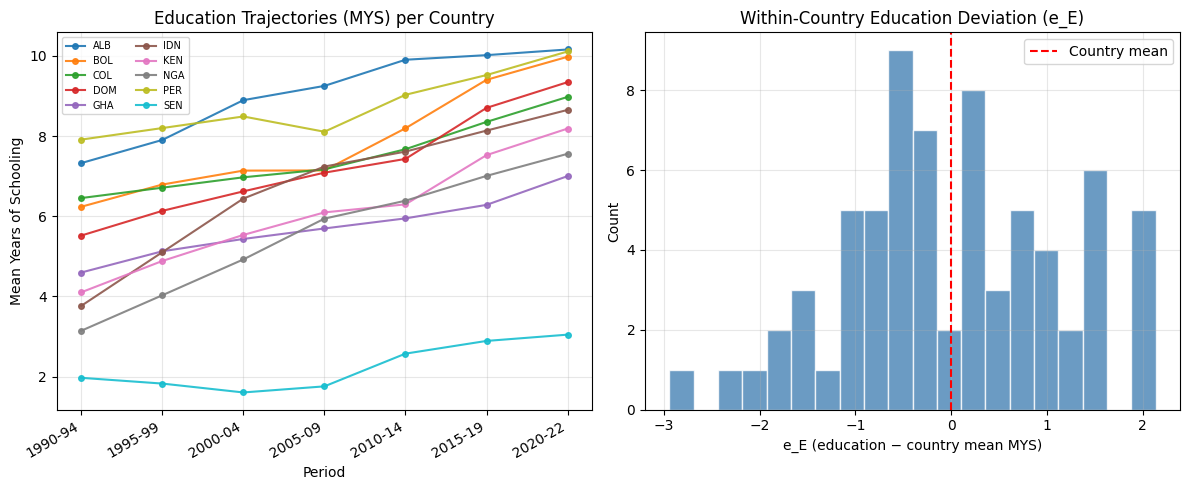

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 1), dpi=FIG_DPI)

# Left: education trajectories per country
ax = axes[0]
countries = sorted(panel["country_code"].unique())
palette = sns.color_palette("tab10", len(countries))
for i, cc in enumerate(countries):
    sub = panel[panel["country_code"] == cc].sort_values("period_id")
    ax.plot(sub["period_id"], sub["education"], marker="o", markersize=4,
            alpha=ALPHA_DOT + 0.2, color=palette[i], label=cc, linewidth=1.5)
ax.set_xlabel("Period")
ax.set_ylabel("Mean Years of Schooling")
ax.set_title("Education Trajectories (MYS) per Country")
ax.set_xticks(sorted(panel["period_id"].unique()))
ax.set_xticklabels([PERIOD_LABELS[k] for k in sorted(panel["period_id"].unique())], rotation=30, ha="right")
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.grid(True, alpha=0.3)

# Right: within-country deviation e_E distribution (how much each obs differs from country mean)
ax2 = axes[1]
panel["e_E"].dropna().hist(bins=20, ax=ax2, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Country mean")
ax2.set_xlabel("e_E (education − country mean MYS)")
ax2.set_ylabel("Count")
ax2.set_title("Within-Country Education Deviation (e_E)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Education → Democracy Pathway

Scatter of education (MYS) vs. liberal democracy index, colored by period. The positive association across periods motivates the main research hypothesis: higher schooling predicts deeper democratic consolidation.

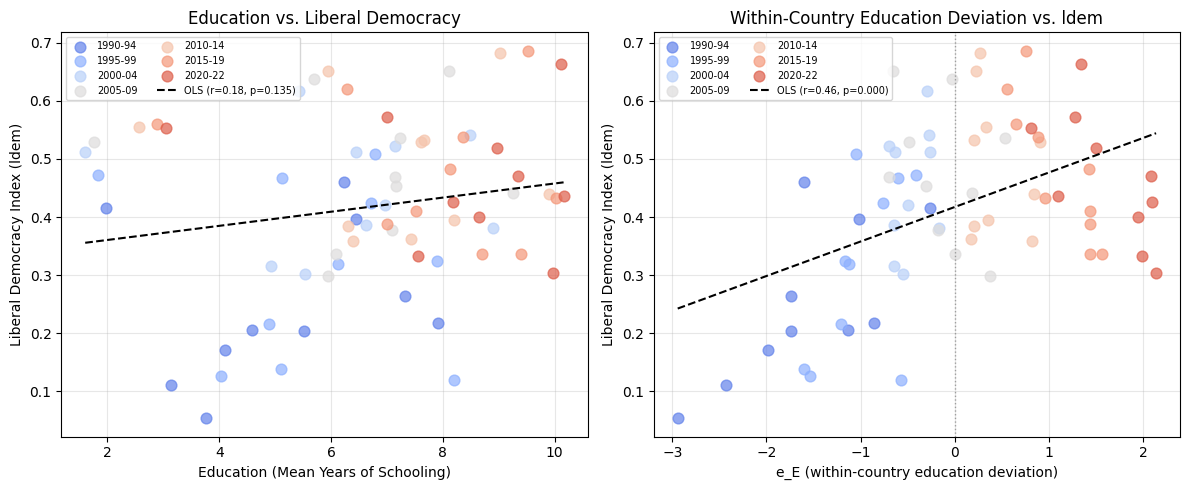

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 1), dpi=FIG_DPI)

period_palette = sns.color_palette("coolwarm", 7)

# Left: education vs ldem (liberal democracy)
ax = axes[0]
sub = panel.dropna(subset=["education", "ldem"])
for pid in sorted(sub["period_id"].unique()):
    s = sub[sub["period_id"] == pid]
    ax.scatter(s["education"], s["ldem"], color=period_palette[pid - 1],
               s=DOT_SIZE, alpha=ALPHA_DOT, label=PERIOD_LABELS[pid], zorder=2)
# Overall OLS trend
if len(sub) > 2:
    m, b, r, p_val, _ = stats.linregress(sub["education"], sub["ldem"])
    x_line = np.linspace(sub["education"].min(), sub["education"].max(), 100)
    ax.plot(x_line, m * x_line + b, "k--", linewidth=1.5, label=f"OLS (r={r:.2f}, p={p_val:.3f})")
ax.set_xlabel("Education (Mean Years of Schooling)")
ax.set_ylabel("Liberal Democracy Index (ldem)")
ax.set_title("Education vs. Liberal Democracy")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Right: education within-deviation (e_E) vs ldem — the within-estimator perspective
ax2 = axes[1]
sub2 = panel.dropna(subset=["e_E", "ldem"])
for pid in sorted(sub2["period_id"].unique()):
    s = sub2[sub2["period_id"] == pid]
    ax2.scatter(s["e_E"], s["ldem"], color=period_palette[pid - 1],
                s=DOT_SIZE, alpha=ALPHA_DOT, label=PERIOD_LABELS[pid], zorder=2)
if len(sub2) > 2:
    m2, b2, r2, p_val2, _ = stats.linregress(sub2["e_E"], sub2["ldem"])
    x2 = np.linspace(sub2["e_E"].min(), sub2["e_E"].max(), 100)
    ax2.plot(x2, m2 * x2 + b2, "k--", linewidth=1.5, label=f"OLS (r={r2:.2f}, p={p_val2:.3f})")
ax2.axvline(0, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax2.set_xlabel("e_E (within-country education deviation)")
ax2.set_ylabel("Liberal Democracy Index (ldem)")
ax2.set_title("Within-Country Education Deviation vs. ldem")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Inequality (Gini) and Social Protection Coverage

`gini_disp` is SWIID disposable-income Gini (cross-nationally comparable). `socprot` is ILO SDG 1.3.1 social protection coverage rate (only available from ~2009). These are two key treatment/control variables in the panel.

/tmp/claude-1000/claude-1000/ipykernel_2706746/284588800.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([PERIOD_LABELS[p] for p in periods_sorted], rotation=30, ha="right")


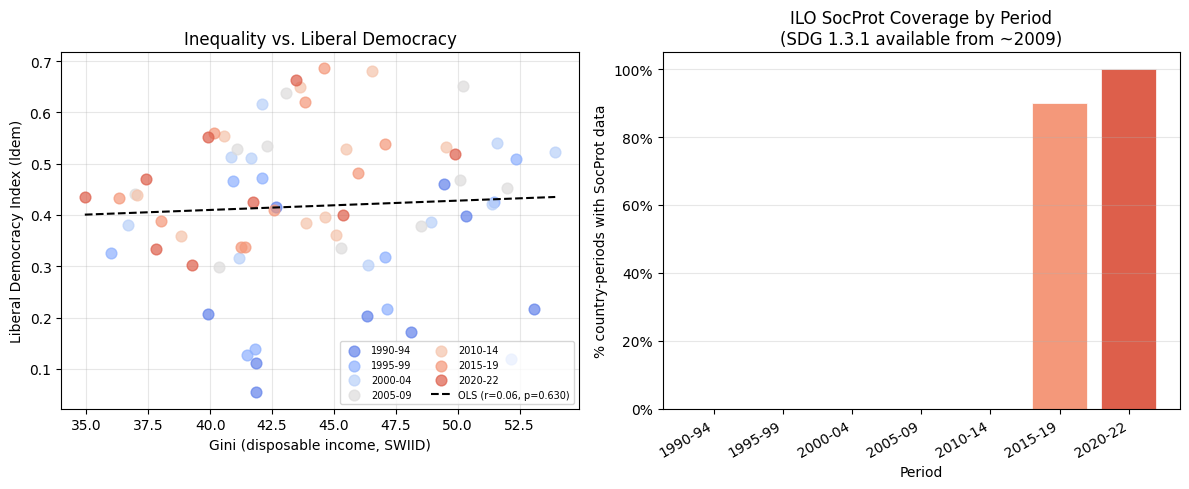

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 1), dpi=FIG_DPI)

# Left: Gini vs ldem
ax = axes[0]
sub_g = panel.dropna(subset=["gini_disp", "ldem"])
for pid in sorted(sub_g["period_id"].unique()):
    s = sub_g[sub_g["period_id"] == pid]
    ax.scatter(s["gini_disp"], s["ldem"], color=period_palette[pid - 1],
               s=DOT_SIZE, alpha=ALPHA_DOT, label=PERIOD_LABELS[pid], zorder=2)
if len(sub_g) > 2:
    mg, bg, rg, pg, _ = stats.linregress(sub_g["gini_disp"], sub_g["ldem"])
    xg = np.linspace(sub_g["gini_disp"].min(), sub_g["gini_disp"].max(), 100)
    ax.plot(xg, mg * xg + bg, "k--", linewidth=1.5, label=f"OLS (r={rg:.2f}, p={pg:.3f})")
ax.set_xlabel("Gini (disposable income, SWIID)")
ax.set_ylabel("Liberal Democracy Index (ldem)")
ax.set_title("Inequality vs. Liberal Democracy")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Right: Social protection coverage availability by period
ax2 = axes[1]
sp_coverage = panel.groupby("period_id")["socprot"].apply(lambda x: x.notna().mean() * 100)
periods_sorted = sorted(sp_coverage.index)
bar_colors = [period_palette[p - 1] for p in periods_sorted]
ax2.bar([PERIOD_LABELS[p] for p in periods_sorted], sp_coverage[periods_sorted],
        color=bar_colors, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Period")
ax2.set_ylabel("% country-periods with SocProt data")
ax2.set_title("ILO SocProt Coverage by Period\n(SDG 1.3.1 available from ~2009)")
ax2.set_xticklabels([PERIOD_LABELS[p] for p in periods_sorted], rotation=30, ha="right")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Summary: Panel Audit Statistics

Reproduces the key audit metrics from `data_audit.json` directly from the demo subset, verifying the panel's integrity.

In [14]:
n_countries    = panel["country_code"].nunique()
n_rows         = len(panel)
n_3plus        = int((panel.groupby("country_code")["period_id"].count() >= 3).sum())
n_complete     = int(panel.dropna(subset=["ldem", "gini_disp", "education"]).shape[0])

# Within-SD education
wcsd_ext = panel.groupby("country_code")["education"].std().mean()
sub_2p   = panel[panel["period_id"].isin([6, 7])]
wcsd_2p  = sub_2p.groupby("country_code")["education"].std().mean()
ratio    = wcsd_ext / wcsd_2p if wcsd_2p and wcsd_2p > 0 else float("nan")

# ILO coverage
n_ilo = int(panel["socprot"].notna().sum())

print("=" * 55)
print("  PANEL AUDIT — DEMO SUBSET (10 of 61 countries)")
print("=" * 55)
print(f"  Countries in demo:          {n_countries}")
print(f"  Country-period rows:        {n_rows}")
print(f"  Countries with ≥3 periods:  {n_3plus}")
print(f"  Rows with ldem+gini+educ:   {n_complete}")
print(f"  ILO SocProt obs:            {n_ilo} / {n_rows}")
print(f"  Within-SD educ (7-period):  {wcsd_ext:.4f}")
print(f"  Within-SD educ (2-period):  {wcsd_2p:.4f}")
print(f"  Ratio:                      {ratio:.2f}x")
print("=" * 55)

  PANEL AUDIT — DEMO SUBSET (10 of 61 countries)
  Countries in demo:          10
  Country-period rows:        70
  Countries with ≥3 periods:  10
  Rows with ldem+gini+educ:   68
  ILO SocProt obs:            19 / 70
  Within-SD educ (7-period):  1.1752
  Within-SD educ (2-period):  0.3657
  Ratio:                      3.21x
